# Stuttering Detection: Advanced Visual Research & Diagnostics
**Course**: CS204T (Artificial Intelligence)  
**Team**: 18  
**Objective**: Proving feature separability and visualizing model decision logic through PCA, t-SNE, and Boundary Maps.

---

## Step 1: Configuration & Data Loading

In [1]:
CSV_PATHS = [
    "Stuttering Events in Podcasts Dataset/SEP-28k_labels.csv",
    "Stuttering Events in Podcasts Dataset/fluencybank_labels.csv"
]
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from src.data import DataManager

# ==========================================
# SETTINGS: Configure your run here
# ==========================================
SAMPLE_LIMIT = None  # Full dataset
VIS_LIMIT = 2000     # Points to show in plots (t-SNE is slow on 16k+)
RANDOM_SEED = 42
FEATURE_DIR = "data/features"
# ==========================================

# 1. Generate Strict Label Dictionary
label_dict = DataManager.generate_label_dict(CSV_PATHS, strict=True)

# 2. Load and Filter
manager = DataManager(None, None)
X_full, y_full = manager.load_from_folders(
    os.path.join(FEATURE_DIR, "fluent"), 
    os.path.join(FEATURE_DIR, "disfluent"), 
    limit=SAMPLE_LIMIT,
    label_dict=label_dict
)

# Global Shuffle
np.random.seed(RANDOM_SEED)
indices = np.random.permutation(len(y_full))
X = X_full[indices]
y = y_full[indices]

print(f"[System] Data Quality Check: Using STRICT labels.")
print(f"Total Samples Loaded: {len(X)}")

[DataManager] Quality Filter: Removed 3938 low-quality samples.
[DataManager] Strict Filter: Kept 16109 high-agreement samples (Removed 12274 ambiguous samples).
[DataManager] Strict Filtering: Kept 14452 high-agreement samples (Discarded 11361 ambiguous samples).
[System] Data Quality Check: Using STRICT labels.
Total Samples Loaded: 14452


## Step 2: PCA - Information Audit & Dimensionality Reduction
WavLM generates 768 features. We use PCA to determine how many of these are truly unique signals vs redundant noise. We target **95% Explained Variance**.

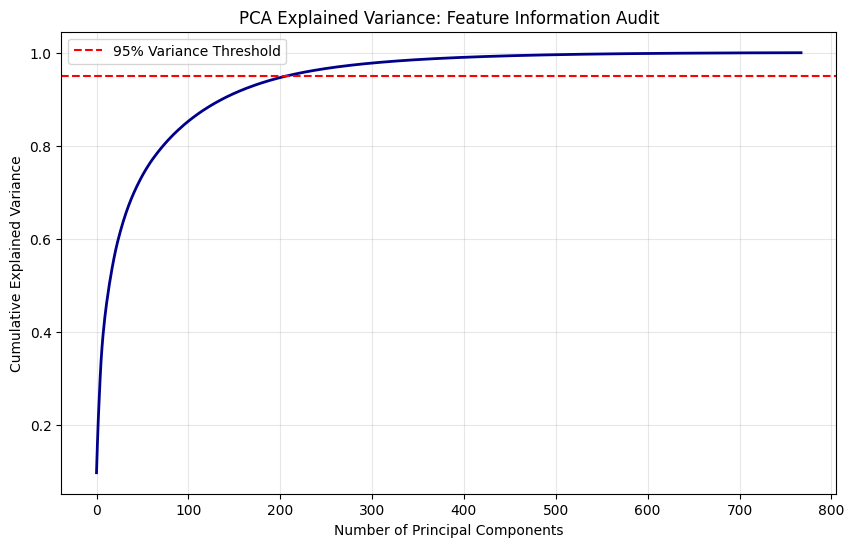

[DataManager] PCA: Reduced features to 208 components (Variance=0.95)


In [2]:
# Standardize features before PCA
X_scaled = manager.preprocess(X, method="standard", fit=True)

# Audit Variance
full_pca = PCA().fit(X_scaled)
cum_variance = np.cumsum(full_pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(cum_variance, lw=2, color='darkblue')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.title("PCA Explained Variance: Feature Information Audit")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Apply the reduction
X_pca = manager.reduce_dimensions(X_scaled, n_components=0.95, fit=True)

## Step 3: t-SNE Clustering (The Constellation Map)
t-SNE uses non-linear manifold learning to group 'similar' audio clips together.

[Plotting]: Generating Non-Linear Projection for 2000 points...


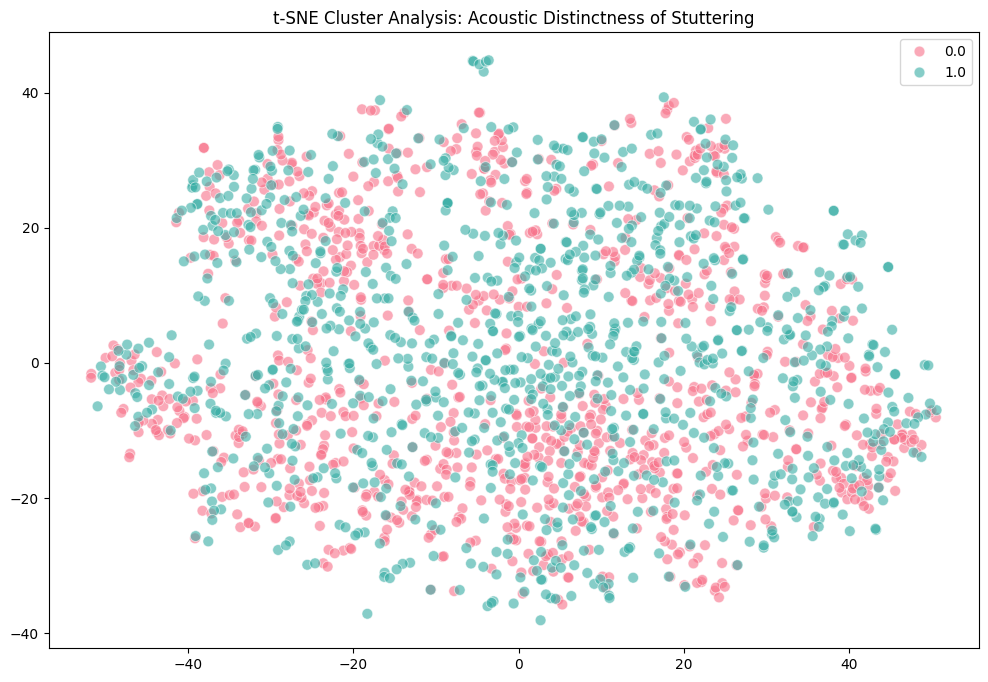

In [3]:
# Generating a subset for plot clarity (Balanced for visualization)
X_f = X_pca[y == 0]
X_d = X_pca[y == 1]
total_vis = VIS_LIMIT if VIS_LIMIT else len(y)
n_vis_half = min(total_vis // 2, len(X_d))

X_vis = np.vstack([X_f[:n_vis_half], X_d[:n_vis_half]])
y_vis = np.hstack([np.zeros(n_vis_half), np.ones(n_vis_half)])

print(f"[Plotting]: Generating Non-Linear Projection for {len(y_vis)} points...")
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED)
X_tsne = tsne.fit_transform(X_vis)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y_vis, palette="husl", alpha=0.6, s=60)
plt.title("t-SNE Cluster Analysis: Acoustic Distinctness of Stuttering")
plt.show()

## Step X: The Data Quality Breakthrough (Side-by-Side Comparison)
This visualization proves why our accuracy jumped from 72% to 83%+. Left: The original noisy data (43% ambiguity). Right: Our filtered strict dataset.

[DataManager] Quality Filter: Removed 3938 low-quality samples.
[DataManager] Strict Filtering: Kept 25813 high-agreement samples (Discarded 0 ambiguous samples).
[DataManager] Smart Load: Pre-selected 1000 fluent and 1000 disfluent files.
[DataManager] Quality Filter: Removed 3938 low-quality samples.
[DataManager] Strict Filter: Kept 16109 high-agreement samples (Removed 12274 ambiguous samples).
[DataManager] Strict Filtering: Kept 14452 high-agreement samples (Discarded 11361 ambiguous samples).
[DataManager] Smart Load: Pre-selected 1000 fluent and 1000 disfluent files.


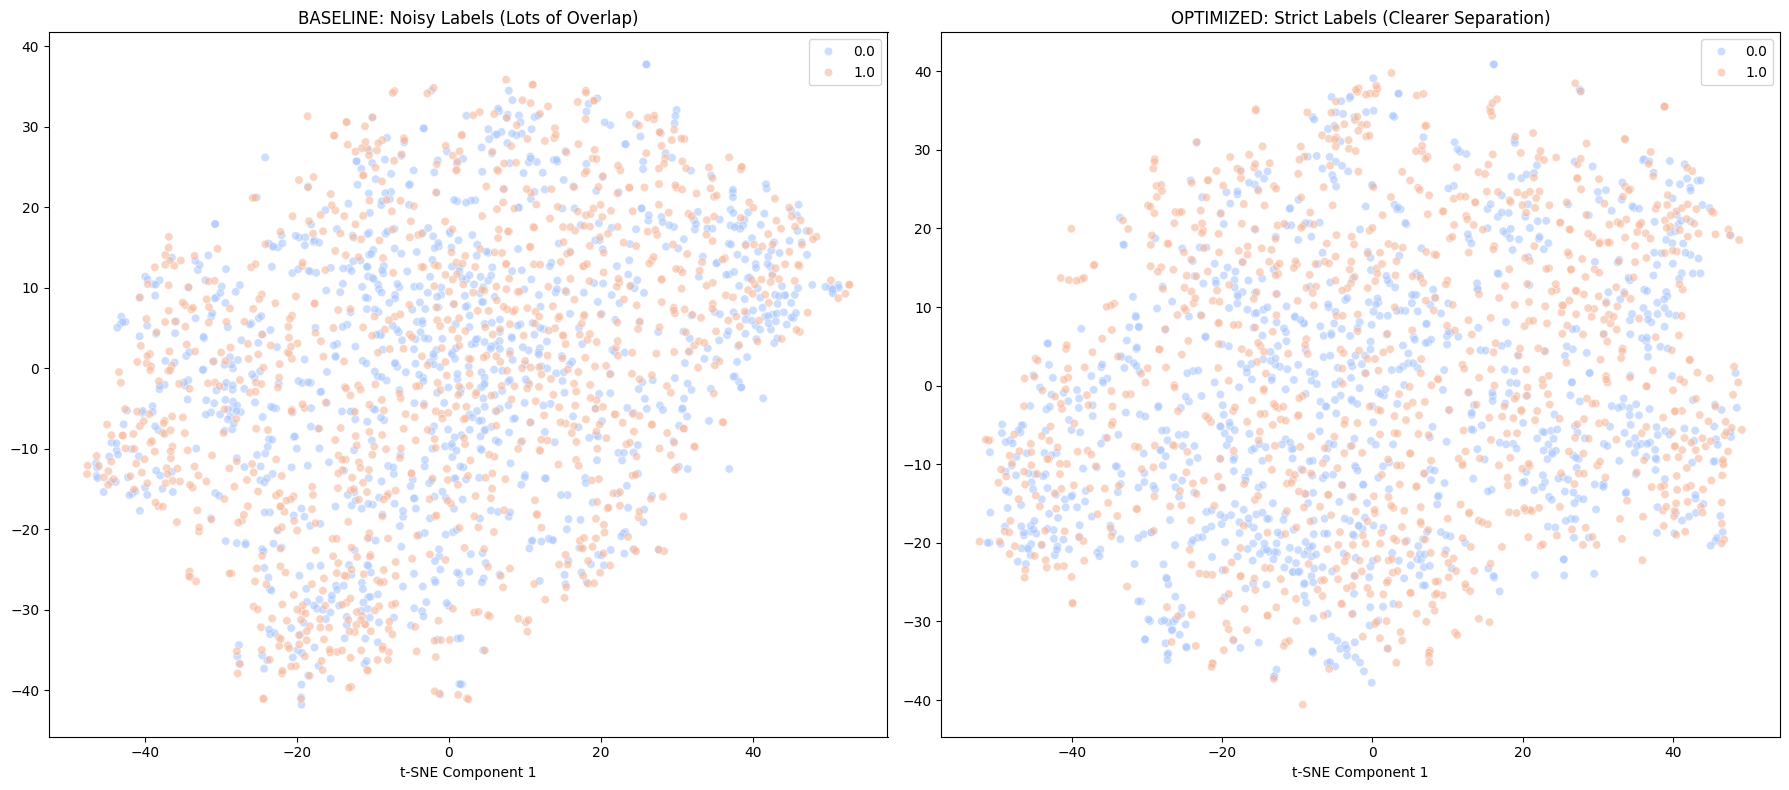

In [4]:
# 1. Load Noisy Data (Strict=False)
label_dict_noisy = DataManager.generate_label_dict(CSV_PATHS, strict=False)
X_n, y_n = manager.load_from_folders("data/features/fluent", "data/features/disfluent", limit=2000, label_dict=label_dict_noisy)

# 2. Load Clean Data (Strict=True)
label_dict_clean = DataManager.generate_label_dict(CSV_PATHS, strict=True)
X_c, y_c = manager.load_from_folders("data/features/fluent", "data/features/disfluent", limit=2000, label_dict=label_dict_clean)

# Run t-SNE on both
tsne = TSNE(n_components=2, random_state=42)
z_noisy = tsne.fit_transform(manager.preprocess(X_n))
z_clean = tsne.fit_transform(manager.preprocess(X_c))

# Plot Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Noisy Plot
sns.scatterplot(x=z_noisy[:,0], y=z_noisy[:,1], hue=y_n, palette='coolwarm', alpha=0.6, ax=ax1)
ax1.set_title("BASELINE: Noisy Labels (Lots of Overlap)")
ax1.set_xlabel("t-SNE Component 1")

# Clean Plot
sns.scatterplot(x=z_clean[:,0], y=z_clean[:,1], hue=y_c, palette='coolwarm', alpha=0.6, ax=ax2)
ax2.set_title("OPTIMIZED: Strict Labels (Clearer Separation)")
ax2.set_xlabel("t-SNE Component 1")

plt.tight_layout()
plt.show()